<a href="https://colab.research.google.com/github/navadeepsaran/AIML_project_and_labs/blob/main/AIML_Module_5_Lab_2_Loss_Functions.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Regression Lab 2: Loss Functions


## Motivation

The main goal of machine learning tasks is to "learn" something about data we feed to our models. But how does the model actually learn anything? To understand this, we need to first understand what objective functions are.

Mathematically, objective functions are a function whose values we desire to minimize/maximize. In the context of machine learning, the objective is commonly referred to as a **loss function**. Loss functions indicate how well the model is doing on the dataset.

The value of the objective function is simply called **loss**. Our goal is to eventually find the best model parameters that has the least average loss on the data after training.


We are familiar with the idea of **error** from the linear regression lab. RMSE is a common loss function used in machine learning. However, there are many other loss functions employed, depending on what the task is (classification, regression etc.). In this lab, we will take a look at some common loss functions, and understand why they are used where they are.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('ggplot')

# interactive visualization

# 1. Regression


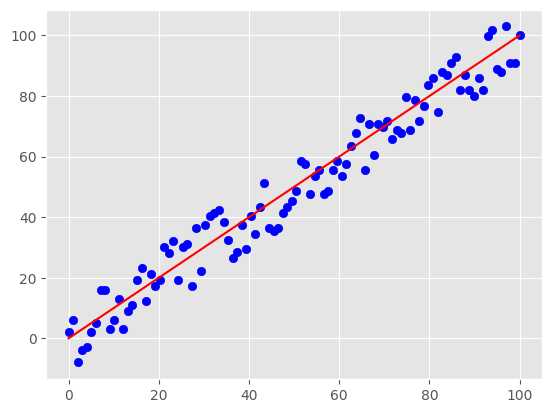

In [2]:
# initializing random data

np.random.seed(0)
x = np.linspace(0,100,100)
y_actual = np.copy(x)
y_pred = x + np.random.randint(-10,10,100)

plt.plot(x,y_actual,color="red")
plt.scatter(x,y_pred,color="blue")
plt.show()

### Mean Squared Error

As we have seen before, the formula for MSE is

$MSE = \frac{1}{m} \sum_{i=1}^n (y-y_p)^2$

The image below depicts a visualization of what the squared error is.

<img src="https://drive.google.com/uc?export=view&id=12jmqRrrqknIWKhwRpgRIJAErBjkEcyx9" width="350" height="350" align="middle"/>

MSE is also referred to as L2 loss.

Typically, we would want the units of error to be the same as the data, so we use Root Mean Squared Error instead.



In [3]:
mse = np.mean((y_actual-y_pred)**2)
print("MSE is: {}".format(mse))
print("RMSE is: {}".format(np.sqrt(mse)))

MSE is: 38.68
RMSE is: 6.219324722186485


### Mean Absolute Error

$MAE = \frac{1}{m} \sum_{i=1}^n |y-y_p|$

MAE is also commonly referred to as L1 loss.

In [4]:
mae = np.mean(np.abs(y_actual-y_pred))
print("MAE is: {}".format(mae))

MAE is: 5.5


MSE penalizes the model for making large errors by squaring the difference. However, this also means that MSE cannot handle outliers well, since they would throw the model off.

On the other hand, MAE is robust to outliers. But, MAE is non-differentiable, making it difficult to perform mathematical operations on it.

Hence, RMSE is most commonly used as a metric for evaluation.

# 2. Classification

Classification tasks involve some data, along with labels assigned to that data. For example, we may have pictures of cats and dogs, and the corresponding labels assigned to those images. We then want to train a model that can predict a label for some input image belonging to either label class (cat or dog).

## The concept of maximum likelihood

Ideally, we would want to obtain a model $\hat{\theta}$ which maximizes the probability of correctly predicting data. Mathematically, the likelihood is:

$ \prod_{i=1}^{N}  \: \hat{\theta_i}^{\theta_i}$

This is because our actual data ($\theta_i$) is either 0 or 1 depending on the label of the data, and our predicted data ($\hat{\theta_i}$) is a probability.

We usually consider the negative log of the likelihood, since log is monotonic and easier to deal with as an optimization problem.

Hence, we have

$MLE = $ arg min $\: - \sum_{i=1}^{N} \theta_i \: log \: \hat{\theta_i}$

\


## Entropy and Cross-Entropy

For some event $x$, we can obtain **information** based on its probability distribution. For example, for some event that occurs with $p=1$, we gain no information. Now, if we flip a coin and see that we obtained heads, we say that we got 1 bit of information.

Thus, the information $I$ of some event $x$ is:

$I = -log_2 \: p(x)$

We say that events with a low probability of occuring give high information, and those with a low probability give low information.

Now, if we have some random variable $X$, its **entropy** is the expected value of the information obtained.

$H(x) = - \sum_{k} p_k \: log \: p_k$

Now, suppose we are trying to correctly predict labels of some data. Let P be the true distribution of the labels, and Q be the predicted distribution of labels.

Cross-Entropy is then defined as:

$H(P,Q) = - \sum_{x} P(x)\: log \: Q(x)$

which is basically the entropy between two probability distributions over the same events.

\


## MLE and Cross-Entropy

So, in the case of classification, the equation for minimization of the cross-entropy between the actual data and the predicted data would be:

arg min $\: -\sum_{i=1}^{N} P(x) \: log \: Q(x)$

$= $ arg min $\: -\sum_{i=1}^{N} \theta_i \: log \: \hat{\theta_i}$


which is exactly the same as what we had obtained for minimizing the negative log likelihood. Hence, the two problems are equivalent.

1/1+e^(-x)

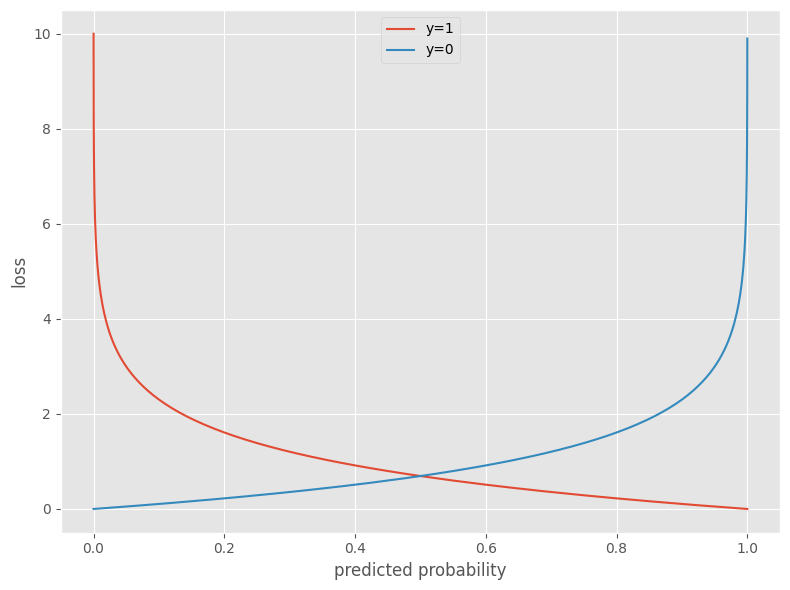

In [5]:
def sigmoid(z):
  return 1/(1 + np.exp(-z))

def cross_entropy_loss(y_,y):
  if y==1:
    return -np.log(y_)

  return -np.log(1-y_)

z = np.arange(-10, 10, 0.1)
h_z = sigmoid(z)

cost_1 = cross_entropy_loss(h_z, 1)
cost_0 = cross_entropy_loss(h_z, 0)

fig, ax = plt.subplots(figsize=(8,6))
plt.plot(h_z, cost_1, label='y=1')
plt.plot(h_z, cost_0, label='y=0')
plt.xlabel('predicted probability')
plt.ylabel('loss')
plt.legend(loc='best')
plt.tight_layout()
plt.show()

## KNN-regression

Till now, we have studied KNN as a classification algorithm, which uses feature similarity and voting to decide the class labels of unseen data.

For regression, we use the same idea: We take the y-values of the k nearest neighbours, and compute their average, which is our predicted y-value. We do this for every x whose value we want to predict.

In the visualization below, we have k=3, and the red dots are the new x-values whose output we want to predict.

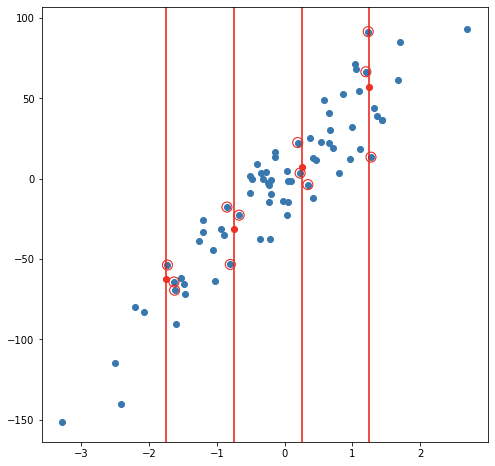

In [6]:
from sklearn import neighbors
from sklearn.metrics import mean_squared_error
from math import sqrt
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
import numpy as np

In [7]:
train_path = "https://raw.githubusercontent.com/PranavTadimeti/Regression-lab2/main/BigMart-train.csv"

train = pd.read_csv(train_path)

In [8]:
# Preprocess Data

def preprocess(df):
  mean_weight = df['Item_Weight'].mean()
  df['Item_Weight'].fillna(mean_weight,inplace=True)

  mode_size = df['Outlet_Size'].mode()
  df['Outlet_Size'].fillna(mode_size,inplace=True)

  df.drop(['Item_Identifier','Outlet_Identifier'],axis=1,inplace=True)

  return pd.get_dummies(df)

train = preprocess(train)

train.head()

/tmp/ipykernel_3117/319556835.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Item_Weight'].fillna(mean_weight,inplace=True)
/tmp/ipykernel_3117/319556835.py:8: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try 

,Item_Weight,Item_Visibility,Item_MRP,Outlet_Establishment_Year,Item_Outlet_Sales,Item_Fat_Content_LF,Item_Fat_Content_Low Fat,Item_Fat_Content_Regular,Item_Fat_Content_low fat,Item_Fat_Content_reg,...,Outlet_Size_High,Outlet_Size_Medium,Outlet_Size_Small,Outlet_Location_Type_Tier 1,Outlet_Location_Type_Tier 2,Outlet_Location_Type_Tier 3,Outlet_Type_Grocery Store,Outlet_Type_Supermarket Type1,Outlet_Type_Supermarket Type2,Outlet_Type_Supermarket Type3
0,9.30,0.016047,249.8092,1999,3735.1380,False,True,False,False,False,...,False,True,False,True,False,False,False,True,False,False
1,5.92,0.019278,48.2692,2009,443.4228,False,False,True,False,False,...,False,True,False,False,False,True,False,False,True,False
2,17.50,0.016760,141.6180,1999,2097.2700,False,True,False,False,False,...,False,True,False,True,False,False,False,True,False,False
3,19.20,0.000000,182.0950,1998,732.3800,False,False,True,False,False,...,False,False,False,False,False,True,True,False,False,False
4,8.93,0.000000,53.8614,1987,994.7052,False,True,False,False,False,...,True,False,False,False,False,True,False,True,False,False


In [9]:
train , test = train_test_split(train, test_size = 0.3)

x_train = train.drop('Item_Outlet_Sales', axis=1)
y_train = train['Item_Outlet_Sales']

x_test = test.drop('Item_Outlet_Sales', axis = 1)
y_test = test['Item_Outlet_Sales']

In [10]:
scaler = MinMaxScaler(feature_range=(0, 1))

x_train_scaled = scaler.fit_transform(x_train)
x_train = pd.DataFrame(x_train_scaled)

x_test_scaled = scaler.fit_transform(x_test)
x_test = pd.DataFrame(x_test_scaled)

In [11]:
def knn_regression(k,x_train,y_train,x_test,y_test):
    model = neighbors.KNeighborsRegressor(n_neighbors = k)

    model.fit(x_train, y_train)
    pred=model.predict(x_test)
    error = sqrt(mean_squared_error(y_test,pred))
    rmse_val.append(error)

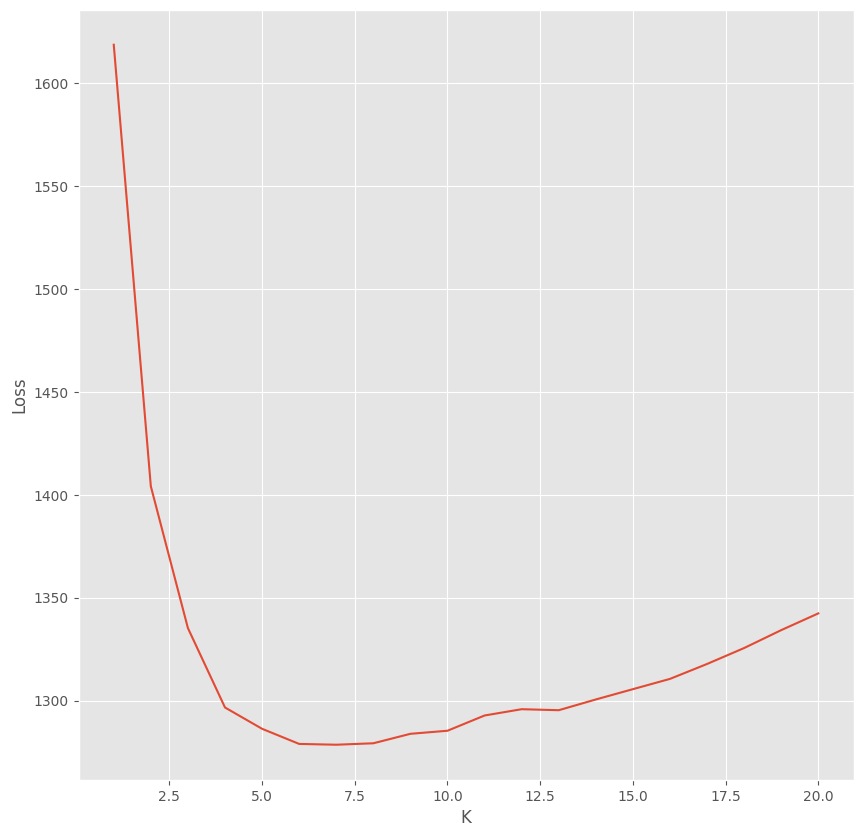

Minimum error 1278.5816281094171 is at k = 6


In [12]:
rmse_val = []

for k in range(1,21):
  knn_regression(k,x_train,y_train,x_test,y_test)

figure = plt.figure(figsize=(10,10))
plt.plot(np.arange(1,21),rmse_val)
plt.xlabel("K")
plt.ylabel("Loss")
plt.show()

rmse_val = np.asarray(rmse_val)
print("Minimum error {} is at k = {}".format(np.min(rmse_val),np.argmin(rmse_val)))

## Exercises

1. Try out these loss functions on regression tasks, and try to understand the model performance based on the loss function.
2. Explore other loss functions and try to understand when and why they are used.
3. Try out KNN-regression on other datasets see which values of K give the best results.
4. Try exploring what will happen if K is set to 1 or K is set to size of whole training dataset.

### Exercise 1: How does the choice of loss function affect the model?

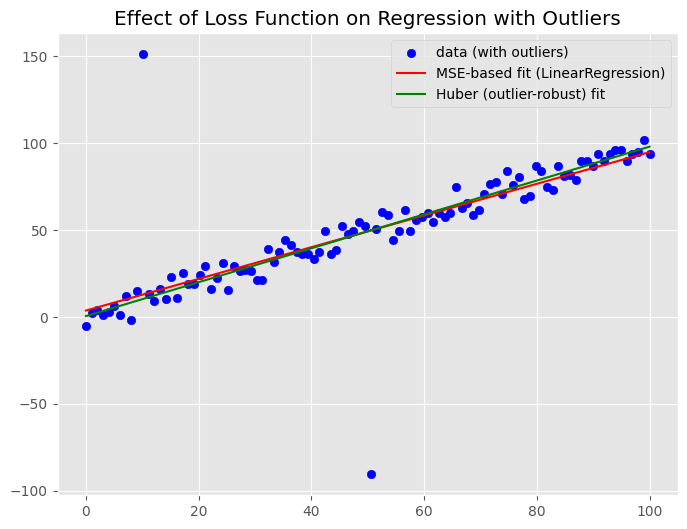

LinearRegression (MSE) slope: 0.9113, intercept: 3.6747
HuberRegressor slope: 0.9747, intercept: 0.4937


In [13]:
from sklearn.linear_model import LinearRegression, HuberRegressor

# reuse the same style of data as the top of the notebook, but inject a couple of extreme outliers
np.random.seed(1)
x_ex1 = np.linspace(0, 100, 100)
y_ex1 = np.copy(x_ex1) + np.random.randint(-10, 10, 100)

y_ex1_outliers = np.copy(y_ex1)
y_ex1_outliers[10] += 150
y_ex1_outliers[50] -= 150

X_ex1 = x_ex1.reshape(-1, 1)

# Model 1: LinearRegression internally minimizes MSE (L2 loss)
mse_model = LinearRegression()
mse_model.fit(X_ex1, y_ex1_outliers)
mse_preds = mse_model.predict(X_ex1)

# Model 2: HuberRegressor uses a loss that's robust to outliers (MSE near zero, MAE-like far away)
huber_model = HuberRegressor()
huber_model.fit(X_ex1, y_ex1_outliers)
huber_preds = huber_model.predict(X_ex1)

plt.figure(figsize=(8,6))
plt.scatter(x_ex1, y_ex1_outliers, color="blue", label="data (with outliers)")
plt.plot(x_ex1, mse_preds, color="red", label="MSE-based fit (LinearRegression)")
plt.plot(x_ex1, huber_preds, color="green", label="Huber (outlier-robust) fit")
plt.legend()
plt.title("Effect of Loss Function on Regression with Outliers")
plt.show()

print("LinearRegression (MSE) slope: {:.4f}, intercept: {:.4f}".format(mse_model.coef_[0], mse_model.intercept_))
print("HuberRegressor slope: {:.4f}, intercept: {:.4f}".format(huber_model.coef_[0], huber_model.intercept_))

**Observation:** With two large outliers injected into the data, the LinearRegression model (which minimizes MSE internally) visibly tilts its fit line toward the outliers, since squaring the error makes those points contribute a disproportionately large penalty. The HuberRegressor's line stays much closer to the bulk of the data, because its loss only behaves quadratically for small residuals and switches to a linear (MAE-like) penalty for large ones. This is a direct demonstration of why MSE is sensitive to outliers while more robust losses aren't.

### Exercise 2: Exploring the Huber Loss function

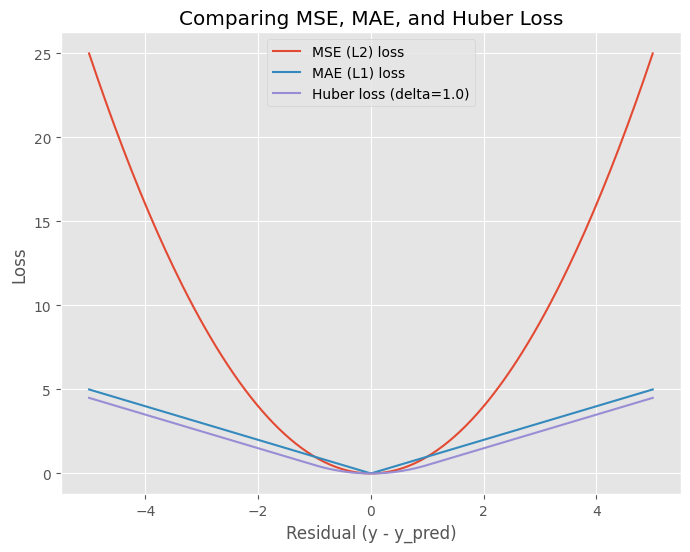

In [14]:
def huber_loss(residual, delta=1.0):
    abs_residual = np.abs(residual)
    quadratic = np.minimum(abs_residual, delta)
    linear = abs_residual - quadratic
    return 0.5 * quadratic**2 + delta * linear

residuals = np.linspace(-5, 5, 200)

mse_loss_vals = residuals**2
mae_loss_vals = np.abs(residuals)
huber_loss_vals = huber_loss(residuals, delta=1.0)

plt.figure(figsize=(8,6))
plt.plot(residuals, mse_loss_vals, label="MSE (L2) loss")
plt.plot(residuals, mae_loss_vals, label="MAE (L1) loss")
plt.plot(residuals, huber_loss_vals, label="Huber loss (delta=1.0)")
plt.xlabel("Residual (y - y_pred)")
plt.ylabel("Loss")
plt.legend()
plt.title("Comparing MSE, MAE, and Huber Loss")
plt.show()

**Observation:** Huber loss is a hybrid of MSE and MAE. For small residuals (|residual| ≤ delta) it's quadratic, matching MSE and staying smooth/differentiable near zero. For large residuals (|residual| > delta) it becomes linear, matching MAE and no longer letting a few large errors dominate the total loss. The plot shows this clearly — the Huber curve tracks the MSE parabola near the center, then flattens into a straight line further out, just like the MAE curve. This makes it a popular choice when your data has some outliers but you still want a loss that's differentiable everywhere (unlike pure MAE).

### Exercise 3: KNN Regression on the California Housing dataset

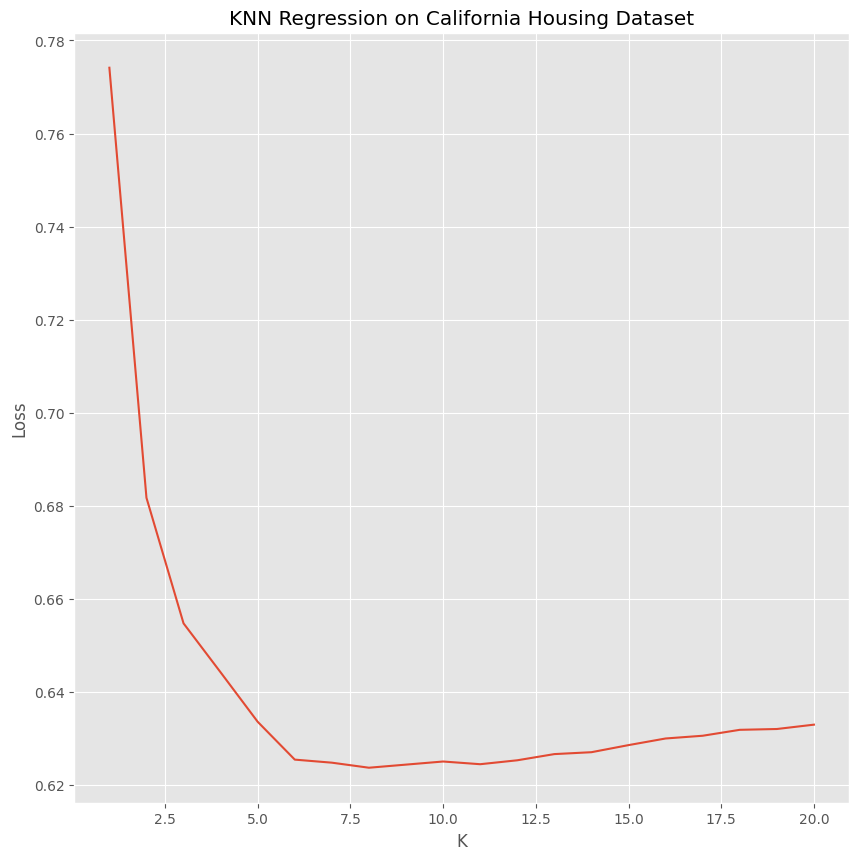

Minimum error 0.6237919515204141 is at k = 8


In [15]:
from sklearn.datasets import fetch_california_housing

housing = fetch_california_housing(as_frame=True)
housing_df = housing.frame

x_housing = housing_df.drop('MedHouseVal', axis=1)
y_housing = housing_df['MedHouseVal']

x_train_h, x_test_h, y_train_h, y_test_h = train_test_split(x_housing, y_housing, test_size=0.3, random_state=42)

scaler_h = MinMaxScaler(feature_range=(0, 1))
x_train_h_scaled = scaler_h.fit_transform(x_train_h)
x_train_h = pd.DataFrame(x_train_h_scaled)

x_test_h_scaled = scaler_h.transform(x_test_h)
x_test_h = pd.DataFrame(x_test_h_scaled)

# knn_regression() (defined earlier in the notebook) appends errors to the global "rmse_val" list,
# so we reset it before this new sweep
rmse_val = []

for k in range(1, 21):
    knn_regression(k, x_train_h, y_train_h, x_test_h, y_test_h)

figure = plt.figure(figsize=(10,10))
plt.plot(np.arange(1,21), rmse_val)
plt.xlabel("K")
plt.ylabel("Loss")
plt.title("KNN Regression on California Housing Dataset")
plt.show()

rmse_val_housing = np.asarray(rmse_val)
best_k = np.argmin(rmse_val_housing) + 1   # +1 because k starts at 1, but list indices start at 0
print("Minimum error {} is at k = {}".format(np.min(rmse_val_housing), best_k))

**Observation:** On the California Housing dataset, RMSE typically drops sharply as k increases from 1 (since averaging over more neighbours smooths out noise), reaches a minimum at some intermediate k, and then slowly rises again as k gets too large (since the model starts averaging over points that aren't actually similar to the query point). The best k found here balances underfitting and overfitting — note it's a different value than the "best k" we found for the BigMart dataset, since the ideal k depends on the size, density, and noise level of the dataset.

### Exercise 4: What happens when K=1 or K = size of the training set?

In [16]:
# K = 1: prediction is just copied from the single nearest neighbour
knn_regression(1, x_train_h, y_train_h, x_test_h, y_test_h)

# K = size of training set: every prediction averages over *all* training points,
# so every test point gets the exact same prediction (the mean of y_train)
k_max = len(x_train_h)
knn_regression(k_max, x_train_h, y_train_h, x_test_h, y_test_h)

print("RMSE at k=1: {:.4f}".format(rmse_val[-2]))
print("RMSE at k={} (all training points): {:.4f}".format(k_max, rmse_val[-1]))

RMSE at k=1: 0.7741
RMSE at k=14448 (all training points): 1.1457


**Observation:** At k=1, the model overfits — each prediction is copied directly from a single nearest neighbour with no smoothing, making it very sensitive to noise in individual training points. At k = size of the training set, the model underfits in the opposite direction — since it always averages over *every* training point regardless of the input, it predicts the same constant value (the mean of y_train) for every test point, effectively ignoring the input features entirely. Both extremes usually give worse RMSE than the "just right" k found in Exercise 3, which is a nice concrete illustration of the bias-variance tradeoff.

## References ##
1. https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.KNeighborsRegressor.html
2. https://www.geeksforgeeks.org/k-nearest-neighbours/
3. https://bookdown.org/tpinto_home/Regression-and-Classification/k-nearest-neighbours-regression.html#:~:text=KNN%20regression%20is%20a%20non,observations%20in%20the%20same%20neighbourhood